In [1]:
!pip install tensorflow matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
dataset_name = "facades"
_URL = f'http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/{dataset_name}.tar.gz'

path_to_zip = tf.keras.utils.get_file(fname=f"{dataset_name}.tar.gz",
                                      origin=_URL,
                                      extract=True)

# Corrected PATH definition
PATH = os.path.join(path_to_zip, dataset_name)

30168306/30168306 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [3]:
IMG_WIDTH = 256
IMG_HEIGHT = 256

def load(image_file):
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)

    w = tf.shape(image)[1] // 2
    real_image = image[:, :w, :]
    input_image = image[:, w:, :]

    real_image = tf.cast(real_image, tf.float32)
    input_image = tf.cast(input_image, tf.float32)

    return input_image, real_image

def resize(input_image, real_image):
    input_image = tf.image.resize(input_image, [IMG_HEIGHT, IMG_WIDTH])
    real_image = tf.image.resize(real_image, [IMG_HEIGHT, IMG_WIDTH])
    return input_image, real_image

def normalize(input_image, real_image):
    input_image = (input_image / 127.5) - 1
    real_image = (real_image / 127.5) - 1
    return input_image, real_image

def load_image_train(image_file):
    input_image, real_image = load(image_file)
    input_image, real_image = resize(input_image, real_image)
    input_image, real_image = normalize(input_image, real_image)
    return input_image, real_image

In [4]:
BUFFER_SIZE = 400
BATCH_SIZE = 1

train_dataset = tf.data.Dataset.list_files(PATH + '/train/*.jpg')
train_dataset = train_dataset.map(load_image_train)
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.take(200)

In [5]:
print(f'Current dataset PATH: {PATH}')

Current dataset PATH: /root/.keras/datasets/facades_extracted/facades


In [6]:
print('Listing contents of PATH:')
!ls {PATH}

Listing contents of PATH:
test  train  val


In [7]:
print('Listing contents of PATH/facades if it exists:')
!ls {PATH}/facades

Listing contents of PATH/facades if it exists:
ls: cannot access '/root/.keras/datasets/facades_extracted/facades/facades': No such file or directory


In [8]:
def downsample(filters, size):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2D(filters, size, strides=2,
                                      padding='same',
                                      kernel_initializer=initializer,
                                      use_bias=False))
    result.add(tf.keras.layers.BatchNormalization())
    result.add(tf.keras.layers.LeakyReLU())
    return result

def upsample(filters, size):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                               padding='same',
                                               kernel_initializer=initializer,
                                               use_bias=False))
    result.add(tf.keras.layers.BatchNormalization())
    result.add(tf.keras.layers.ReLU())
    return result

def Generator():
    inputs = tf.keras.layers.Input(shape=[256,256,3])

    down_stack = [
        downsample(64,4),
        downsample(128,4),
        downsample(256,4),
    ]

    up_stack = [
        upsample(256,4),
        upsample(128,4),
        upsample(64,4),
    ]

    x = inputs
    skips = []

    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])

    last = tf.keras.layers.Conv2DTranspose(3,4,
                                           strides=2,
                                           padding='same',
                                           activation='tanh')

    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)

generator = Generator()

In [9]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = tf.keras.layers.Input(shape=[256,256,3])
    tar = tf.keras.layers.Input(shape=[256,256,3])

    x = tf.keras.layers.concatenate([inp, tar])

    down1 = downsample(64,4)(x)
    down2 = downsample(128,4)(down1)

    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down2)
    conv = tf.keras.layers.Conv2D(256,4,
                                 strides=1,
                                 kernel_initializer=initializer,
                                 use_bias=False)(zero_pad1)

    batchnorm = tf.keras.layers.BatchNormalization()(conv)
    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm)

    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu)
    last = tf.keras.layers.Conv2D(1,4,
                                 strides=1,
                                 kernel_initializer=initializer)(zero_pad2)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)

discriminator = Discriminator()

In [10]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    return gan_loss + (100 * l1_loss)

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    fake_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + fake_loss

In [11]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [12]:
@tf.function
def train_step(input_image, target):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_loss,
                                            generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss,
                                                 discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients,
                                            generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                discriminator.trainable_variables))

In [13]:
EPOCHS = 50

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}")

    for input_image, target in train_dataset:
        train_step(input_image, target)

Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50


In [14]:
def generate_images(model, test_input, tar):
    prediction = model(test_input, training=True)

    plt.figure(figsize=(12,4))
    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Image', 'Ground Truth', 'Generated Image']

    for i in range(3):
        plt.subplot(1,3,i+1)
        plt.title(title[i])
        plt.imshow((display_list[i] + 1) / 2)
        plt.axis('off')
    plt.show()

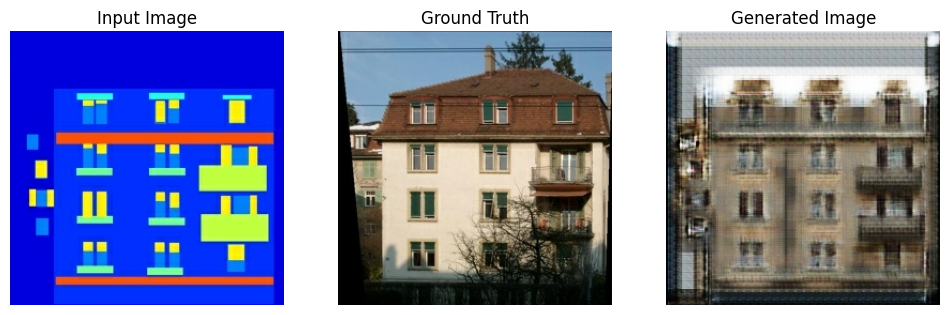

In [15]:
for example_input, example_target in train_dataset.take(1):
    generate_images(generator, example_input, example_target)